# **Machine Learning — Model Development and Fairness Evaluation**

## Objectives

* Quantify the distortion introduced by the leaked `duration` feature identified in Notebook 02
* Build a deployable targeting model that excludes leakage
* Evaluate performance using metrics appropriate to an 8:1 class imbalance, not accuracy
* Measure whether the model's targeting falls evenly across age band and education level
* Produce a documented recommendation on whether the model should be deployed

## Inputs

* Data_Set/clean_data/v1/bank_marketing_cleaned.csv — cleaned dataset from Notebook 01

## Outputs

* Data_Set/models/v1/ — fitted model pipelines
* Data_Set/outputs/v1/model_comparison.csv — performance metrics
* Data_Set/outputs/v1/fairness_metrics.csv — subgroup disparity summary
* Data_Set/outputs/v1/fairness_by_group.csv — per-group fairness detail
* Data_Set/outputs/v1/figures/ — leakage, confusion matrix, feature importance and fairness charts

## Additional Comments

* Accuracy is not reported as a headline metric. At an 11% positive rate, a model predicting
  "no" for every client scores 89% accuracy while identifying nobody. ROC-AUC, recall and
  precision are used instead.

* Model A retains `duration` and exists solely to quantify what leakage does to apparent
  performance. It is never a deployment candidate. Model B excludes it and is carried forward.

* Age, education, job and marital status are excluded from the model's feature set but
  retained in the dataset, because they are required to measure whether targeting falls
  evenly across groups. This is the reasoning recorded in Notebook 01: demographics are
  analysed, not modelled.

* Fairness is measured using demographic parity difference and equal opportunity difference.
  These two definitions cannot generally be satisfied simultaneously, and the choice between
  them is stated rather than assumed.

* A false positive here means a client contacted who had no interest. For a client in a group
  more likely to be considered vulnerable, repeated unsolicited contact is a harm in itself,
  not a wasted call.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'/Users/apple/Desktop/fair-marketing-analytics/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'/Users/apple/Desktop/fair-marketing-analytics'

# Section 1 — Setup and Feature Preparation

In [5]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

version = 'v1'
clean_dir = f'Data_Set/clean_data/{version}'
output_dir = f'Data_Set/outputs/{version}'
model_dir = f'Data_Set/models/{version}'
fig_dir = f'{output_dir}/figures'

os.makedirs(model_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

RANDOM_STATE = 42

PALETTE = {
    'blue': '#0072B2', 'orange': '#E69F00', 'green': '#009E73',
    'red': '#D55E00', 'grey': '#999999',
}

plt.rcParams.update({
    'figure.figsize': (10, 6), 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

print(f"Models to {model_dir}")
print(f"Outputs to {output_dir}")

Models to Data_Set/models/v1
Outputs to Data_Set/outputs/v1


In [6]:
df = pd.read_csv(f'{clean_dir}/bank_marketing_cleaned.csv')
print(f"{len(df):,} records, {df.shape[1]} columns")
print(f"Positive rate: {df['subscribed'].mean():.2%}")

41,176 records, 23 columns
Positive rate: 11.27%


## Feature sets

Two feature sets are defined.

**Set A** retains `duration`. Notebook 02 confirmed this field is target leakage: it is not
known when a targeting decision is made, and rank-biserial correlation with the outcome was
-0.637. Set A exists only to quantify how much apparent performance leakage buys. It is not
a deployment candidate.

**Set B** excludes `duration`. It retains campaign, macroeconomic and client-status
variables but excludes `age`, `age_band`, `job`, `education` and `marital`. Those fields
remain in the dataset for fairness measurement but are not model inputs, following the
reasoning recorded in Notebook 01. Set B is the deployment candidate.

`default_disclosed` is retained because Notebook 01 established that the original `default`
field recorded only three positive cases and functioned as a disclosure indicator. Whether a
model should reward disclosure is revisited in Section 5.

In [7]:
demographic = ['age', 'age_band', 'job', 'education', 'marital']
leakage = ['duration']

campaign = ['contact', 'month', 'day_of_week', 'campaign', 'pdays',
            'previous', 'poutcome', 'contacted_before']
macro = ['emp_var_rate', 'cons_price_idx', 'cons_conf_idx',
         'euribor3m', 'nr_employed']
client = ['housing', 'loan', 'default_disclosed']

FEATURES = {
    'A_with_leakage': campaign + macro + client + leakage,
    'B_deployable':   campaign + macro + client,
}

for name, cols in FEATURES.items():
    print(f"{name}: {len(cols)} features")

A_with_leakage: 17 features
B_deployable: 16 features


In [8]:
X_all = df.drop(columns=['subscribed'])
y = df['subscribed']

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {len(X_train_all):,}  positive rate {y_train.mean():.2%}")
print(f"Test:  {len(X_test_all):,}  positive rate {y_test.mean():.2%}")

Train: 30,882  positive rate 11.27%
Test:  10,294  positive rate 11.27%


The split is stratified so both sets retain the 11% positive rate. Without stratification a
random split could hand the test set a materially different class balance and make the
performance figures unreliable.

The full feature frame is split once and subset per model afterwards, so both models are
evaluated on exactly the same clients. This also preserves the demographic columns in the
test set for the fairness analysis in Section 4, even though they are not model inputs.

---

# Section 2 — Model Training

In [9]:
def build_pipeline(features, model, df_reference):
    """Construct a preprocessing and modelling pipeline for a given feature set.

    Numeric features are median-imputed and standardised. Categorical features are
    imputed with a constant 'missing' category and one-hot encoded. Imputing rather
    than dropping preserves the records where information was never captured, which
    Notebook 01 identified as a structural gap rather than random missingness.

    Args:
        features: list of column names to use as model inputs.
        model: an unfitted scikit-learn estimator.
        df_reference: DataFrame used to infer column data types.

    Returns:
        An unfitted sklearn Pipeline.
    """
    num = [c for c in features if df_reference[c].dtype != 'object']
    cat = [c for c in features if df_reference[c].dtype == 'object']

    numeric_steps = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ])

    categorical_steps = Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_steps, num),
        ('cat', categorical_steps, cat),
    ])

    return Pipeline([('prep', preprocessor), ('model', model)])

In [10]:
def evaluate(pipeline, X_test, y_test, label):
    """Evaluate a fitted pipeline using metrics appropriate to an imbalanced target.

    Accuracy is recorded for reference only. At an 11% positive rate a model predicting
    the negative class for every client scores 89% accuracy while identifying nobody,
    so ROC-AUC, recall and precision carry the assessment.

    Args:
        pipeline: a fitted sklearn Pipeline.
        X_test: test feature frame.
        y_test: test labels.
        label: name recorded against the results row.

    Returns:
        dict of performance metrics.
    """
    pred = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]

    return {
        'model': label,
        'accuracy': round(accuracy_score(y_test, pred), 4),
        'precision': round(precision_score(y_test, pred, zero_division=0), 4),
        'recall': round(recall_score(y_test, pred, zero_division=0), 4),
        'f1': round(f1_score(y_test, pred, zero_division=0), 4),
        'roc_auc': round(roc_auc_score(y_test, proba), 4),
    }

In [11]:
baseline = {
    'model': 'Baseline (predict "no" for all)',
    'accuracy': round((y_test == 0).mean(), 4),
    'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.5,
}

print(f"Baseline accuracy: {baseline['accuracy']:.2%} — identifies zero subscribers")

Baseline accuracy: 88.73% — identifies zero subscribers


In [12]:
results = [baseline]
fitted = {}

# Random Forest is used for both feature sets. Chart 6 in Notebook 03 showed that age and
# occupation each carry signal independently of the other, so a model capable of
# representing interactions is appropriate. Using one algorithm across both sets means the
# only difference between them is the presence of the leaked field.
for set_name, features in FEATURES.items():
    label = f'{set_name} | RandomForest'
    pipe = build_pipeline(
        features,
        RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                               random_state=RANDOM_STATE,
                               class_weight='balanced', n_jobs=-1),
        df
    )
    pipe.fit(X_train_all[features], y_train)
    results.append(evaluate(pipe, X_test_all[features], y_test, label))
    fitted[label] = pipe
    print(f"trained {label}")

comparison = pd.DataFrame(results)
comparison.to_csv(f'{output_dir}/model_comparison.csv', index=False)
comparison

trained A_with_leakage | RandomForest
trained B_deployable | RandomForest


,model,accuracy,precision,recall,f1,roc_auc
0,"Baseline (predict ""no"" for all)",0.8873,0.0000,0.0000,0.0000,0.5000
1,A_with_leakage | RandomForest,0.8860,0.4966,0.8888,0.6372,0.9484
2,B_deployable | RandomForest,0.8380,0.3700,0.6233,0.4644,0.7939


`class_weight='balanced'` is applied. Without it, an 8:1 imbalance drives the model towards
predicting the majority class, producing high accuracy and near-zero recall. Weighting makes
the model identify subscribers at the cost of more false positives — a trade-off examined in
Section 4, since a false positive here means contacting someone who did not want to be
contacted.

In [13]:
best_label = 'B_deployable | RandomForest'
best_model = fitted[best_label]

joblib.dump(best_model, f'{model_dir}/deployment_model.joblib')
joblib.dump(fitted['A_with_leakage | RandomForest'],
            f'{model_dir}/leakage_comparison_model.joblib')

print(f"Deployment candidate: {best_label}")
print(f"Saved to {model_dir}/")

Deployment candidate: B_deployable | RandomForest
Saved to Data_Set/models/v1/


# Section 3 — Performance and the Cost of Leakage

In [14]:
comp = comparison[comparison['model'] != baseline['model']].copy()
comp['set'] = comp['model'].str.split(' | ').str[0]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(['Set A\n(retains duration)', 'Set B\n(leakage removed)'],
              comp['roc_auc'], color=[PALETTE['red'], PALETTE['blue']], width=0.55)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=12)

ax.axhline(0.5, color='black', linestyle=':', linewidth=1.5)
ax.text(1.42, 0.515, 'random guessing', fontsize=9, ha='right')

ax.set_ylabel('ROC-AUC')
ax.set_ylim(0, 1.05)
ax.set_title('Set A retains the leaked duration field. Its apparent advantage is not\n'
             'available at the moment a targeting decision is taken.')

fig.savefig(f'{fig_dir}/08_leakage_comparison.png')
plt.show()

<Figure size 900x600 with 1 Axes>

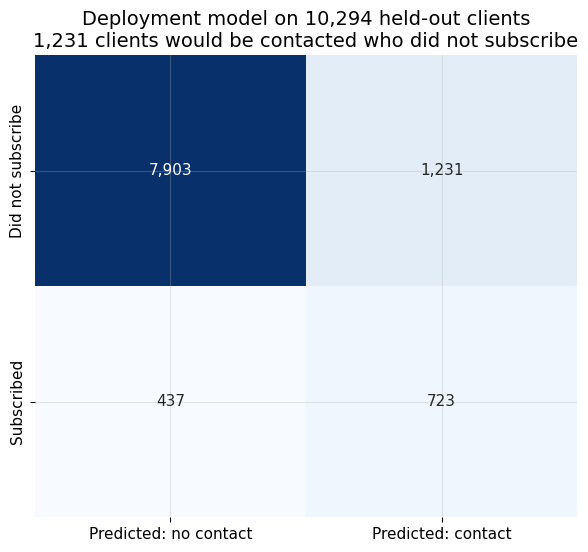

                   precision    recall  f1-score   support

Did not subscribe       0.95      0.87      0.90      9134
       Subscribed       0.37      0.62      0.46      1160

         accuracy                           0.84     10294
        macro avg       0.66      0.74      0.68     10294
     weighted avg       0.88      0.84      0.85     10294



In [15]:
pred = best_model.predict(X_test_all[FEATURES['B_deployable']])
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: no contact', 'Predicted: contact'],
            yticklabels=['Did not subscribe', 'Subscribed'], ax=ax)

ax.set_title(f'Deployment model on {len(y_test):,} held-out clients\n'
             f'{fp:,} clients would be contacted who did not subscribe')

fig.savefig(f'{fig_dir}/09_confusion_matrix.png')
plt.show()

print(classification_report(y_test, pred,
                            target_names=['Did not subscribe', 'Subscribed']))

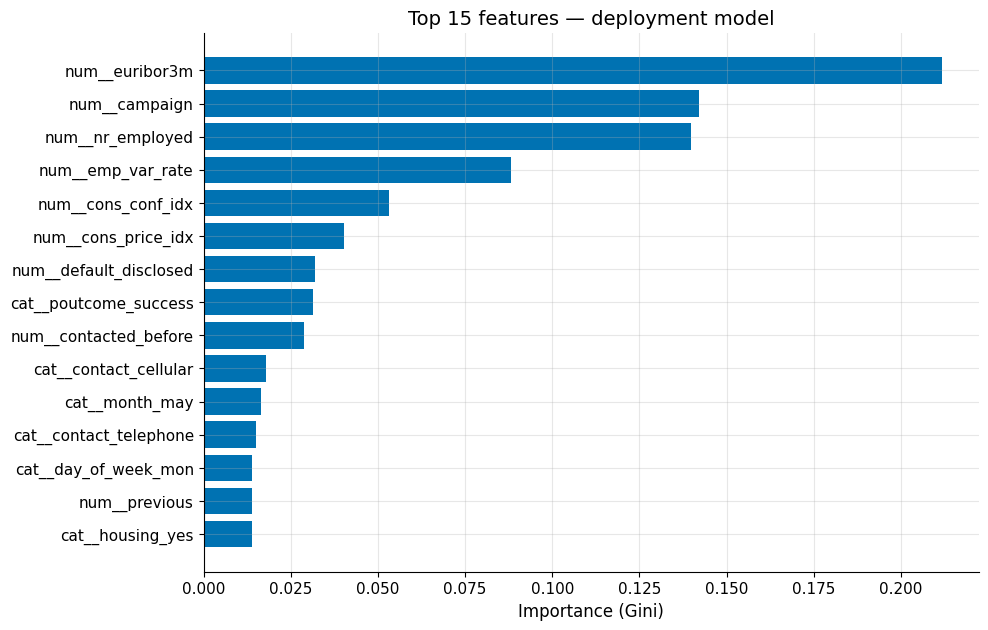

,feature,importance
7,num__euribor3m,0.211658
0,num__campaign,0.141994
8,num__nr_employed,0.139696
4,num__emp_var_rate,0.088204
6,num__cons_conf_idx,0.053102
5,num__cons_price_idx,0.040365
9,num__default_disclosed,0.031951
29,cat__poutcome_success,0.031378
3,num__contacted_before,0.028841
10,cat__contact_cellular,0.017978


In [17]:
feature_names = best_model.named_steps['prep'].get_feature_names_out()
importance = best_model.named_steps['model'].feature_importances_

imp = (pd.DataFrame({'feature': feature_names, 'importance': importance})
       .sort_values('importance', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp['feature'][::-1], imp['importance'][::-1], color=PALETTE['blue'])
ax.set_xlabel('Importance (Gini)')
ax.set_title('Top 15 features — deployment model')

fig.savefig(f'{fig_dir}/10_feature_importance.png')
plt.show()

imp.head(10)

# Section 4 — Fairness Evaluation

## Why two definitions, and what they trade off

Two fairness measures are computed, because they answer different questions and cannot
generally both be satisfied.

**Demographic parity** asks whether groups are targeted at equal rates. It ignores whether
members of each group actually wanted the product. Here, enforcing it would mean contacting
clients aged 60 and over at the same rate as everyone else, despite the observed 39.6%
against 10.1% difference in subscription.

**Equal opportunity** asks whether the model finds genuine subscribers equally well within
each group. It permits unequal targeting rates where underlying rates genuinely differ.

The definition adopted is **equal opportunity**, on the grounds that the model's purpose is
to identify interested clients and the underlying rates are not equal. That choice is stated
rather than assumed, because it carries a consequence: adopting equal opportunity means
accepting that clients aged 60 and over will be contacted disproportionately often. Whether
that is acceptable is a conduct judgement, not a statistical one, and it is addressed in
Section 5.

Demographic parity difference is reported alongside, because it is the measure that shows
the disproportion equal opportunity permits.

## What a false positive costs here

A false positive is a client the model recommends contacting who does not subscribe. In a
commercial frame this is a wasted call. In a conduct frame it is unsolicited contact with
someone who did not want the product.

The false positive rate is therefore reported by group. If the model produces materially
more false positives among clients aged 60 and over, it directs unwanted contact
disproportionately towards a group more likely to be treated as vulnerable under FCA rules.
That is the metric a conduct reviewer would look at first, and it is not visible in any
aggregate performance figure.

In [18]:
def group_metrics(y_true, y_pred, groups):
    """Compute per-group fairness metrics for a binary classifier.

    Groups with fewer than 30 members are excluded, since rates calculated from cells
    that small are unstable and would misrepresent the finding.

    Args:
        y_true: array of true labels.
        y_pred: array of predicted labels.
        groups: array of group membership labels, same length as y_true.

    Returns:
        DataFrame indexed by group with base rate, selection rate, true positive rate,
        false positive rate, precision and group size.
    """
    rows = []
    for g in pd.Series(groups).dropna().unique():
        mask = (groups == g)
        yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
        if len(yt) < 30:
            continue

        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

        rows.append({
            'group': g,
            'n': int(mask.sum()),
            'base_rate': round(yt.mean(), 4),
            'selection_rate': round(yp.mean(), 4),
            'true_positive_rate': round(tp / (tp + fn), 4) if (tp + fn) else np.nan,
            'false_positive_rate': round(fp / (fp + tn), 4) if (fp + tn) else np.nan,
            'precision': round(tp / (tp + fp), 4) if (tp + fp) else np.nan,
        })

    return pd.DataFrame(rows).set_index('group')


def disparity(metrics):
    """Summarise disparity across groups as max-minus-min differences.

    Args:
        metrics: DataFrame returned by group_metrics.

    Returns:
        dict of demographic parity, equal opportunity and false positive rate differences.
    """
    return {
        'demographic_parity_diff': round(
            metrics['selection_rate'].max() - metrics['selection_rate'].min(), 4),
        'equal_opportunity_diff': round(
            metrics['true_positive_rate'].max() - metrics['true_positive_rate'].min(), 4),
        'false_positive_rate_diff': round(
            metrics['false_positive_rate'].max() - metrics['false_positive_rate'].min(), 4),
    }

In [19]:
test_ref = X_test_all.copy()
test_ref['y_true'] = y_test.values
test_ref['y_pred'] = pred

fairness_tables = {}
summary_rows = []

for attribute in ['age_band', 'education']:
    m = group_metrics(test_ref['y_true'], test_ref['y_pred'], test_ref[attribute])
    m = m.sort_values('selection_rate', ascending=False)
    fairness_tables[attribute] = m

    d = disparity(m)
    d['attribute'] = attribute
    summary_rows.append(d)

    print(f"\n=== {attribute} ===")
    print(m.to_string())
    print(f"  demographic parity difference:  {d['demographic_parity_diff']}")
    print(f"  equal opportunity difference:   {d['equal_opportunity_diff']}")
    print(f"  false positive rate difference: {d['false_positive_rate_diff']}")


=== age_band ===
                n  base_rate  selection_rate  true_positive_rate  false_positive_rate  precision
group                                                                                           
60 and over   283     0.4346          0.8092              0.9024               0.7375     0.4847
Under 25      272     0.2279          0.4081              0.8065               0.2905     0.4505
25-59        9739     0.1001          0.1657              0.5764               0.1200     0.3482
  demographic parity difference:  0.6435
  equal opportunity difference:   0.326
  false positive rate difference: 0.6175

=== education ===
                        n  base_rate  selection_rate  true_positive_rate  false_positive_rate  precision
group                                                                                                   
university.degree    3076     0.1398          0.2464              0.7047               0.1720     0.3997
professional.course  1313     0.1257     

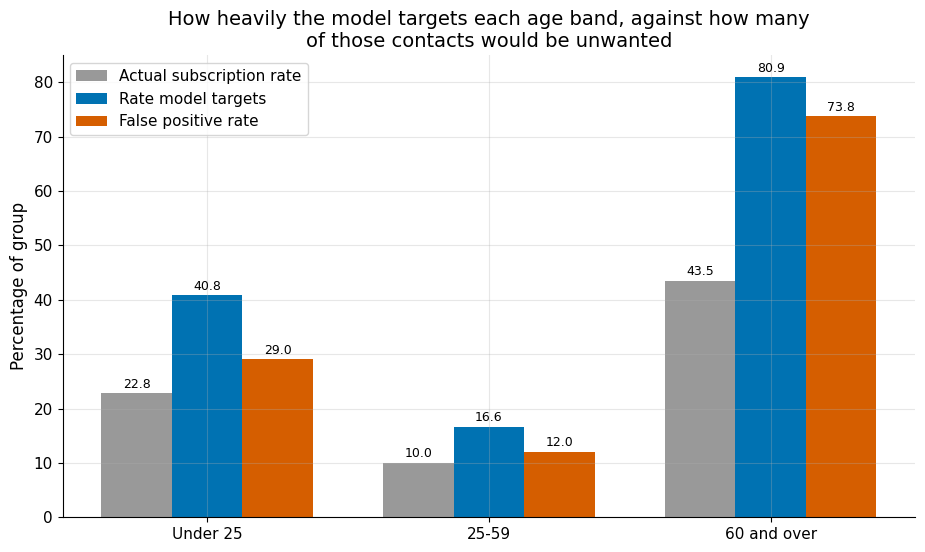

In [20]:
age_m = fairness_tables['age_band'].reindex(
    ['Under 25', '25-59', '60 and over']).dropna()

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(age_m))
w = 0.25

ax.bar(x - w, age_m['base_rate'] * 100, w,
       label='Actual subscription rate', color=PALETTE['grey'])
ax.bar(x, age_m['selection_rate'] * 100, w,
       label='Rate model targets', color=PALETTE['blue'])
ax.bar(x + w, age_m['false_positive_rate'] * 100, w,
       label='False positive rate', color=PALETTE['red'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(age_m.index)
ax.set_ylabel('Percentage of group')
ax.set_title('How heavily the model targets each age band, against how many\n'
             'of those contacts would be unwanted')
ax.legend()

fig.savefig(f'{fig_dir}/11_fairness_by_age.png')
plt.show()

In [21]:
fairness_summary = pd.DataFrame(summary_rows)[
    ['attribute', 'demographic_parity_diff',
     'equal_opportunity_diff', 'false_positive_rate_diff']
]
fairness_summary.to_csv(f'{output_dir}/fairness_metrics.csv', index=False)

detail = pd.concat(fairness_tables, names=['attribute']).reset_index()
detail.to_csv(f'{output_dir}/fairness_by_group.csv', index=False)

print(f"Saved to {output_dir}/")
fairness_summary

Saved to Data_Set/outputs/v1/


,attribute,demographic_parity_diff,equal_opportunity_diff,false_positive_rate_diff
0,age_band,0.6435,0.3260,0.6175
1,education,0.1324,0.3367,0.0923


# Section 5 — Deployment Recommendation



## What the model does well

Set B achieves ROC-AUC of 0.7939 against a random-guessing baseline of 0.5. Applied to the
10,294 held-out clients, it recommends contacting 1,954 and correctly identifies 723 of the
1,160 who subscribed. Contacting 19% of the list captures 62% of all subscribers, and the
37.0% precision represents a 3.3-fold improvement on the 11.3% base rate.

Accuracy is 83.8%, which is lower than the 88.7% achieved by predicting "no" for every
client. This is the expected result and the reason accuracy was excluded as a headline
metric at the outset: the baseline achieves its score by identifying nobody.

## What leakage would have concealed

Set A, retaining `duration`, reports ROC-AUC of 0.9484, recall of 0.8888 and precision of
0.4966. Set B reports 0.7939, 0.6233 and 0.3700. Removing a single leaked field costs 0.155
of ROC-AUC and over a quarter of recall.

None of Set A's advantage is real. Notebook 02 established that call duration is not known
when the targeting decision is taken and is effectively determined by the outcome. A model
risk process reviewing headline metrics alone would have approved a model reporting 0.95
ROC-AUC that cannot function in production. The gap between the two figures is the practical
value of feature-level validation.

## Where the targeting falls

| Age band | n | Actual rate | Model targets | False positive rate | Finds subscribers |
|---|---|---|---|---|---|
| 60 and over | 283 | 43.5% | 80.9% | 73.8% | 90.2% |
| Under 25 | 272 | 40.8%* | 40.8% | 29.1% | 80.7% |
| 25 to 59 | 9,739 | 10.0% | 16.6% | 12.0% | 57.6% |

*Under-25 actual rate is 22.8%.

The model recommends contacting 80.9% of all clients aged 60 and over, against 16.6% of the
25 to 59 group. Demographic parity difference is 0.6435.

The false positive rate is the figure a conduct function would examine first. Among clients
aged 60 and over who would not have subscribed, 73.8% are recommended for contact — roughly
118 of the 160 such clients in the test set. The equivalent figure for the 25 to 59 group is
12.0%. False positive rate difference is 0.6175.

Stated plainly: the model directs unwanted contact at clients aged 60 and over at six times
the rate it does at the working-age majority. Under FCA vulnerable customer guidance and the
Consumer Duty obligation to avoid foreseeable harm, unsolicited repeat contact with an older
customer is not a neutral cost.

## The model fails the fairness standard adopted in Section 4

Section 4 adopted equal opportunity as the operative definition, on the grounds that
underlying subscription rates genuinely differ by age and the model's purpose is to identify
interested clients. That standard was chosen before the metrics were computed.

The model does not meet it. Equal opportunity difference on age band is 0.3260: the model
identifies 90.2% of genuine subscribers aged 60 and over but only 57.6% of those aged 25 to
59. The disparity is therefore not confined to targeting volume. The model is materially
better at serving one group than another on the precise measure selected to permit unequal
targeting.

## The choice of fairness definition determines what is visible

Education demonstrates this directly.

| Measure | Age band | Education |
|---|---|---|
| Demographic parity difference | 0.6435 | 0.1324 |
| Equal opportunity difference | 0.3260 | 0.3367 |
| False positive rate difference | 0.6175 | 0.0923 |

On demographic parity, education appears close to even. On equal opportunity it is the worse
of the two attributes: the model finds 70.5% of genuine subscribers among clients with a
university degree and 36.8% among those with basic 9y schooling.

An assessment reporting demographic parity alone would have concluded that education presents
no fairness concern. That conclusion would have been wrong, and it would have been wrong in
the direction that favours deployment. This is why the definition adopted is stated explicitly
rather than assumed, and why both measures are reported.

## Removing demographic data does not remove demographic disparity

The deployment model contains no demographic inputs. Age, age band, job, education and
marital status were excluded from Set B at the outset, following the reasoning recorded in
Notebook 01. The model has never seen a client's age.

It nevertheless produces a demographic parity difference of 0.6435 across age bands.

The disparity is carried by proxies. Campaign fields including prior contact history, contact
channel and previous campaign outcome encode who the bank has approached before and how, and
that history is not independent of age. Chart 6 in Notebook 03 anticipated this: age and
occupation each carried signal independently of the other, indicating the pattern is
distributed across the data rather than confined to any one field.

Fairness through unawareness does not work on this dataset. Deleting protected characteristics
from the feature set removes the ability to measure disparity, not the disparity itself.

## What the model is actually predicting

Five macroeconomic variables — `euribor3m` (0.212), `nr_employed` (0.140), `emp_var_rate`
(0.088), `cons_conf_idx` (0.053) and `cons_price_idx` (0.040) — account for approximately 53%
of total feature importance. `campaign`, the number of contacts made, accounts for a further
0.142.

Over half the model's predictive power therefore derives from the economic environment rather
than from any characteristic of the client. The campaign ran from May 2008 to November 2010,
a period in which euro interbank rates fell sharply and employment contracted. The model has
substantially learned the relationship between a specific economic episode and demand for
fixed-term deposits.

This limits transferability severely. Deployed under different macroeconomic conditions, the
model has no established basis for its principal signal.

`default_disclosed` carries importance of 0.032. Notebook 01 established that the underlying
field recorded three positive cases in 41,188 records and functioned as an indicator of
whether the client answered the question. The model is therefore assigning weight to
disclosure behaviour rather than to credit risk, which is not a defensible basis for a
targeting decision.

## Recommendation

**Do not deploy in its current form.**

The model is commercially effective and its performance is genuine once leakage is removed.
The recommendation rests on three findings, any one of which would warrant referral:

1. It fails the fairness standard adopted before testing. Equal opportunity difference of
   0.326 on age and 0.337 on education means the model serves some groups materially worse
   than others on the measure selected as the operative one.

2. It directs unwanted contact disproportionately at older clients. A 73.8% false positive
   rate among clients aged 60 and over, against 12.0% for the working-age majority, is a
   foreseeable-harm question under the Consumer Duty rather than a matter of campaign
   efficiency.

3. Its principal signal is a macroeconomic episode from 2008 to 2010. Over half of feature
   importance sits in variables describing the economy, not the client.

## Conditions for reconsideration

The model could be reconsidered subject to the following, each tied to a specific finding
above:

- **Recalibrate thresholds by group** and re-measure equal opportunity difference. The
  current disparity arises at a single global threshold; group-specific thresholds may
  reduce it, at a stated cost to overall recall.
- **Cap contact frequency**, particularly for clients aged 60 and over. H4 in Notebook 02
  found repeated contact associated with lower subscription, so a cap is supported by the
  data as well as by conduct considerations.
- **Remove `default_disclosed`** from the feature set. It rewards disclosure rather than
  measuring risk.
- **Retrain on a period spanning more than one interest rate environment**, or remove the
  macroeconomic block and accept the reduction in performance in exchange for a model whose
  signal derives from client and campaign characteristics.
- **Permanently exclude `duration`** from any future build, with the exclusion documented in
  the model specification rather than left to the modeller.
- **Monitor false positive rate by age band as a live control** with a defined threshold and
  escalation route, rather than as a one-off pre-deployment test. The disparity arose from
  proxies, so it can re-emerge after retraining without any change to the feature set.

## What would change this assessment

The recommendation is a judgement made under stated uncertainty, not a verdict.

Group sizes for the two outer age bands are small — 283 and 272 clients in the test set —
so the rates reported for them carry meaningful uncertainty. A larger sample could narrow the
measured disparity, though the direction of the finding is consistent with the descriptive
analysis in Notebook 03 across the full dataset.

The assessment would also change if the product itself were different. A term deposit sold to
an older customer is not inherently unsuitable, and this analysis does not claim that it is.
The concern is the volume of unsolicited contact directed at that group and the absence of
any control on it, not the product. A campaign operating on customers who had given prior
consent to marketing contact, or one offering a product with a different harm profile, would
warrant a different conclusion on the same metrics.

Finally, the framing device stated in Notebook 01 remains a limitation. The data describes a
Portuguese bank between 2008 and 2010. It is assessed here against UK law and FCA rules as a
proxy exercise, not as a finding about any actual UK firm.

---

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [16]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)